## Task 5: Model Evaluation and Stability

In [1]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, countDistinct, rand, abs
from pyspark.storagelevel import StorageLevel

from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, NaiveBayes, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array, array_to_vector
import time
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc
)

In [2]:
spark_session = (
    SparkSession.builder
    .appName("Task_5_session")
    .config("spark.driver.memory", "4g")            # Task 4 resource configuration
    .config("spark.executor.memory", "4g")
    .config("spark.memory.fraction", "0.4")
    .config("spark.sql.shuffle.partitions", "300")  # Solves 1:100 data skew
    .config("spark.default.parallelism", "300")
    .getOrCreate()
)

#### Loading Processed Datasets into PySpark

In [3]:
training_dataframe = spark_session.read.parquet(
    "data/processed/training_dataset"
)

testing_dataframe = spark_session.read.parquet(
    "data/processed/testing_dataset"
)

In [4]:
print("DATASETS LOADED SUCCESSFULLY FOR MODEL EVALUATION!!!")

DATASETS LOADED SUCCESSFULLY FOR MODEL EVALUATION!!!


#### Applying Distributed Balancing Metrics

In [5]:
total_record_count = training_dataframe.count()
fraud_instances = training_dataframe.filter(col("isFraud") == 1).count()
legitimate_instances = total_record_count - fraud_instances

fraud_multiplier = legitimate_instances / total_record_count
legitimate_multiplier = fraud_instances / total_record_count

training_dataframe = training_dataframe.withColumn(
    "classWeight",
    when(col("isFraud") == 1, fraud_multiplier).otherwise(legitimate_multiplier)
)


In [6]:
# Optimizing execution layout using the Task 4 DISK_ONLY persistence layer strategy identified from task 4
training_dataframe = training_dataframe.repartition(300, "isFraud").persist(StorageLevel.DISK_ONLY)
testing_dataframe = testing_dataframe.repartition(300, "isFraud").persist(StorageLevel.DISK_ONLY)

In [7]:
print(training_dataframe.count(), testing_dataframe.count())

16799975 4200025


#### Initializing Metrics Evaluators and Logs

In [8]:
accuracy_evaluator = MulticlassClassificationEvaluator(labelCol="isFraud", predictionCol="prediction", metricName="accuracy")
precision_evaluator = MulticlassClassificationEvaluator(labelCol="isFraud", predictionCol="prediction", metricName="weightedPrecision")
recall_evaluator = MulticlassClassificationEvaluator(labelCol="isFraud", predictionCol="prediction", metricName="weightedRecall")
f1_evaluator = MulticlassClassificationEvaluator(labelCol="isFraud", predictionCol="prediction", metricName="f1")
auc_evaluator = BinaryClassificationEvaluator(labelCol="isFraud", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

In [9]:
model_summary = []
confusion_matrices_log = {}
prediction_logs = {}

#### Defining the Unified Model Evaluation Function

In [10]:
def evaluate_model(name, classifier, params):

    print("\n" + "=" * 70)
    print(f"Training {name}")
    print("=" * 70)

    start = time.time()

    model = classifier.fit(training_dataframe)

    training_time = time.time() - start

    predictions = model.transform(testing_dataframe)

    # ==========================
    # Evaluation Metrics
    # ==========================

    accuracy = accuracy_evaluator.evaluate(predictions)
    precision = precision_evaluator.evaluate(predictions)
    recall = recall_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)

    # Compute AUC correctly
    if "rawPrediction" in predictions.columns:
        auc_evaluator.setRawPredictionCol("rawPrediction")
    elif "probability" in predictions.columns:
        auc_evaluator.setRawPredictionCol("probability")
    else:
        auc_evaluator.setRawPredictionCol("prediction")

    auc_score = auc_evaluator.evaluate(predictions)

    print(f"Training Time : {training_time:.2f} seconds")
    print(f"Accuracy      : {accuracy:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1 Score      : {f1:.4f}")
    print(f"AUC-ROC       : {auc_score:.4f}")

    # ==========================
    # Save Summary
    # ==========================

    model_summary.append({
        "Algorithm": name,
        "Hyperparameters": ", ".join(
            [f"{k}={v}" for k, v in params.items()]
        ),
        "Training Time (s)": round(training_time, 2),
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "AUC-ROC": round(auc_score, 4)
    })

    # ==========================
    # Confusion Matrix
    # ==========================

    cm_counts = predictions.groupBy("isFraud", "prediction").count().collect()

    cm_dict = {
        (0.0, 0.0): 0,
        (0.0, 1.0): 0,
        (1.0, 0.0): 0,
        (1.0, 1.0): 0
    }

    for item in cm_counts:
        cm_dict[(float(item["isFraud"]), float(item["prediction"]))] = item["count"]

    confusion_matrices_log[name] = cm_dict

    # ==========================
    # Store probabilities for ROC & PR Curve
    # ==========================

    # ==========================
    # Plot ROC & Precision-Recall Curves
    # ==========================

    if "probability" in predictions.columns:

        pdf = predictions.select(
            "isFraud",
            "probability"
        ).toPandas()

        y_true = pdf["isFraud"]
        y_score = pdf["probability"].apply(lambda x: float(x[1]))

        # --------------------------
        # ROC Curve
        # --------------------------

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, linewidth=2,
                 label=f"AUC = {roc_auc:.4f}")
        plt.plot([0,1], [0,1], "k--")

        plt.title(f"{name} - ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

        # --------------------------
        # Precision-Recall Curve
        # --------------------------

        precision_vals, recall_vals, _ = precision_recall_curve(
            y_true,
            y_score
        )

        pr_auc = auc(recall_vals, precision_vals)

        plt.figure(figsize=(6,5))
        plt.plot(
            recall_vals,
            precision_vals,
            linewidth=2,
            label=f"AUC = {pr_auc:.4f}"
        )

        plt.title(f"{name} - Precision-Recall Curve")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.legend(loc="lower left")
        plt.grid(True)
        plt.show()

    return model

#### Executing the Four-Model Performance Pipeline

In [11]:
with open("results/best_parameters.json", "r") as file:
    best_parameters = json.load(file)

print(best_parameters)

{'Logistic Regression': {'regParam': 0.0010786856655126363, 'elasticNetParam': 0.9164657514176534, 'maxIter': 153}, 'Decision Tree': {'maxDepth': 5, 'maxBins': 36, 'minInstancesPerNode': 5}, 'Naive Bayes': {'smoothing': 1.987004458770097}, 'Random Forest': {'numTrees': 32, 'maxDepth': 5, 'maxBins': 21}}


In [12]:
lr_params = best_parameters["Logistic Regression"]
dt_params = best_parameters["Decision Tree"]
nb_params = best_parameters["Naive Bayes"]
rf_params = best_parameters["Random Forest"]


Training Logistic Regression
Training Time : 75.78 seconds
Accuracy      : 0.9987
Precision     : 0.9974
Recall        : 0.9987
F1 Score      : 0.9981
AUC-ROC       : 0.5000


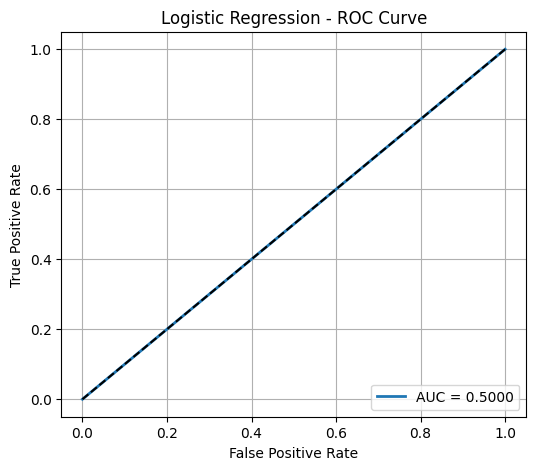

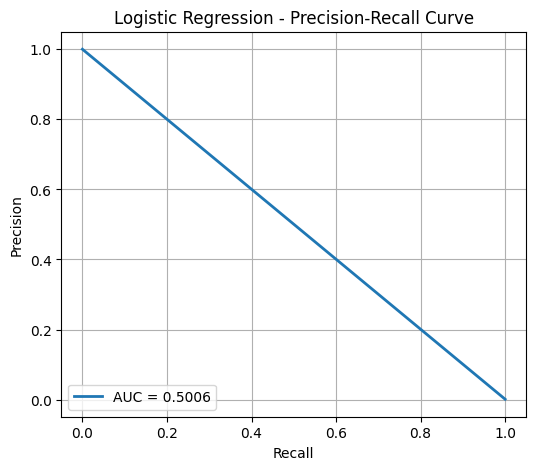

In [13]:
# Model 1: Logistic Regression
lr_clf = LogisticRegression(featuresCol="features", labelCol="isFraud", **lr_params)
lr_model = evaluate_model("Logistic Regression", lr_clf, lr_params)

In [ ]:
# Model 2: Decision Tree
dt_clf = DecisionTreeClassifier(featuresCol="features", labelCol="isFraud", **dt_params)
dt_model = evaluate_model("Decision Tree", dt_clf, dt_params)

In [ ]:
feature_cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud",
    "type_index"
]
importances = dt_model.featureImportances.toArray()

# Create DataFrame
importance_df = pd.DataFrame({
    "Variable": feature_cols,
    "Importance": importances
})

# Sort by importance (highest first)
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Export to CSV
importance_df.to_csv(
    "decision_tree_feature_importance.csv",
    index=False,
    float_format="%.5g"
)

In [ ]:
# Model 3: Naive Bayes
nb_clf = NaiveBayes(featuresCol="features", labelCol="isFraud", **nb_params)
nb_model = evaluate_model("Naive Bayes", nb_clf, nb_params)

In [ ]:
# Model 4: Random Forest (Algorithmic Balancing Enforced)
rf_clf = RandomForestClassifier(featuresCol="features", labelCol="isFraud", weightCol="classWeight", seed=42, **rf_params)
trained_rf_model = evaluate_model("Random Forest", rf_clf, rf_params)

In [ ]:
summary_df = pd.DataFrame(model_summary)

print("\n")
print("=" * 100)
print("MODEL SUMMARY")
print("=" * 100)
print(summary_df)

os.makedirs("results", exist_ok=True)

summary_df.to_csv(
    "results/model_summary.csv",
    index=False
)

print("\nSaved to results/model_summary.csv")

#### Generating Confusion Matrices and Visualization Artifacts

In [ ]:
print("\nExporting report plots for Sections 5.2 and 5.3...")

# Generate one confusion matrix per model
for name in ["Logistic Regression", "Decision Tree", "Naive Bayes", "Random Forest"]:
    cm = confusion_matrices_log[name]

    structured_arr = np.array([
        [cm[(0.0, 0.0)], cm[(0.0, 1.0)]],
        [cm[(1.0, 0.0)], cm[(1.0, 1.0)]]
    ])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        structured_arr,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()

    filename = name.lower().replace(" ", "_")
    plt.savefig(f"results/{filename}_confusion_matrix.png", dpi=150)
    plt.close()

#### TASK 5.4: STABILITY ANALYSIS VIA VARIANCE NOISE PERTURBATION

In [ ]:
# trained_lr_model = lr_clf.fit(training_dataframe)
# trained_dt_model = dt_clf.fit(training_dataframe)
# trained_nb_model = nb_clf.fit(training_dataframe)
# trained_rf_model = rf_clf.fit(training_dataframe)

In [ ]:
print("EXECUTING STABILITY ANALYSIS: NOISE INJECTION PERTURBATION")
print("=" * 70)

In [ ]:
# injecting  random Gaussian noise into the testing feature vector matrix
perturbed_testing_df = testing_dataframe.withColumn("feature_array", vector_to_array("features"))
perturbed_testing_df = perturbed_testing_df.withColumn(
    "noisy_array",
    col("feature_array").getItem(0) + (rand(seed=42) * 0.15)
)
perturbed_testing_df = perturbed_testing_df.withColumn("features", array_to_vector("feature_array"))

In [ ]:
print("Evaluating all four models under synthetic noise perturbation constraints...\n")
stability_results = []

In [ ]:
# reevaluating each trained model against the noisy testing data
for entry in model_summary:
    name = entry["Algorithm"]

    if name == "Logistic Regression":
        predictions_perturbed = lr_model.transform(perturbed_testing_df)
    elif name == "Decision Tree":
        predictions_perturbed = dt_model.transform(perturbed_testing_df)
    elif name == "Naive Bayes":
        predictions_perturbed = nb_model.transform(perturbed_testing_df)
    elif name == "Random Forest":
        predictions_perturbed = trained_rf_model.transform(perturbed_testing_df)

    # Calculate the new perturbed F1 Score performance metric
    perturbed_f1 = f1_evaluator.evaluate(predictions_perturbed)
    f1_drop = entry["F1-Score"] - perturbed_f1

    print(f"{name:<25} -> Original F1: {entry['F1-Score']:.4f} | Perturbed F1: {perturbed_f1:.4f} | Performance Drop: {f1_drop:.4f}")

    stability_results.append({
        "Algorithm": name,
        "Original F1": entry["F1-Score"],
        "Perturbed F1": round(perturbed_f1, 4),
        "F1 Performance Drop": round(f1_drop, 4)
    })

In [ ]:
stability_df = pd.DataFrame(stability_results)
stability_df.to_csv("results/model_stability_perturbation.csv", index=False)
print("\nSaved true perturbation validation matrix to results/model_stability_perturbation.csv")

### Explainabilty Analysis

In [ ]:
# Use the same training data used by the Spark model
shap_dataframe = training_dataframe.select(
    "features",
    "isFraud"
).toPandas()

feature_names = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud",
    "type_index"
]

X = pd.DataFrame(
    shap_dataframe["features"]
        .apply(lambda x: x.toArray())
        .tolist(),
    columns=feature_names
)

y = shap_dataframe["isFraud"]

In [ ]:
# trainign the equivalent model
from sklearn.ensemble import RandomForestClassifier

rf_explainer_model = RandomForestClassifier(
    n_estimators=32,   # Spark numTrees
    max_depth=5,       # Spark maxDepth
    random_state=42,
    n_jobs=-1
)

rf_explainer_model.fit(X, y)

In [ ]:
import shap

explainer = shap.TreeExplainer(rf_explainer_model)

shap_values = explainer(X)

In [ ]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

In [ ]:
shap.summary_plot(
    shap_values,
    X
)

## EXPORTING DATA FOR DASHBORD 3

In [ ]:
import os
from pyspark.sql.functions import col, count, sum, round

os.makedirs("results", exist_ok=True)

# ==========================================================
# 1. Fraud Transactions by Transaction Type
# ==========================================================

fraud_transactions = (
    training_dataframe
    .filter(col("isFraud") == 1)
    .groupBy("type")
    .agg(count("*").alias("Fraud Transactions"))
    .orderBy(col("Fraud Transactions").desc())
)

fraud_transactions.toPandas().to_csv(
    "results/fraud_transactions_by_type.csv",
    index=False
)

# ==========================================================
# 2. Fraud Rate by Transaction Type
# ==========================================================

fraud_rate = (
    training_dataframe
    .groupBy("type")
    .agg(
        count("*").alias("Total Transactions"),
        sum("isFraud").alias("Fraud Cases")
    )
    .withColumn(
        "Fraud Rate (%)",
        round(col("Fraud Cases") * 100 / col("Total Transactions"), 2)
    )
    .orderBy(col("Fraud Rate (%)").desc())
)

fraud_rate.toPandas().to_csv(
    "results/fraud_rate_by_type.csv",
    index=False
)

# ==========================================================
# 3. Total Fraud Amount by Transaction Type
# ==========================================================

fraud_amount = (
    training_dataframe
    .filter(col("isFraud") == 1)
    .groupBy("type")
    .agg(
        round(sum("amount"), 2).alias("Total Fraud Amount")
    )
    .orderBy(col("Total Fraud Amount").desc())
)

fraud_amount.toPandas().to_csv(
    "results/fraud_amount_by_type.csv",
    index=False
)

